# Project Title: Shopper Spectrum - Customer Segmentation & Recommendations[cite: 2]

## 1. Problem Statement & Business Objective
The global e-commerce industry generates vast amounts of transaction data daily[cite: 2]. Without proper analysis, businesses cannot identify high-value buyers or recommend relevant products[cite: 2]. This project implements:
1. **Unsupervised Machine Learning (KMeans Clustering)** for RFM customer segmentation[cite: 2].
2. **Collaborative Filtering (Cosine Similarity)** for product recommendations[cite: 2].

## 2. Dataset Selection Justification
We have chosen the Online Retail Dataset because it contains transactional attributes like InvoiceNo, StockCode, Quantity, InvoiceDate, UnitPrice, and CustomerID[cite: 2]. These are critical for calculating Recency, Frequency, and Monetary (RFM) values, making it perfect for real-world e-commerce analytics[cite: 2].

In [2]:
import pandas as pd
import numpy as np


df = pd.read_csv('../data/online_retail.csv') 


print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

Dataset Shape: (541909, 8)

Missing Values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Data Types:
 InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object


### Data Cleaning Justifications:
1. **Remove Missing CustomerID:** Customers with missing IDs cannot be tracked or segmented[cite: 2].
2. **Exclude Cancelled Invoices:** Invoice numbers starting with 'C' are cancellations and will distort our actual sales analysis[cite: 2].
3. **Filter Positive Quantity & Price:** Negative or zero values are errors or returns and should be removed[cite: 2].

In [3]:
# 1. Remove rows where CustomerID is missing[cite: 2]
df_clean = df.dropna(subset=['CustomerID']).copy()

# 2. Exclude cancelled invoices where InvoiceNo starts with 'C'[cite: 2]
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# 3. Remove rows with negative or zero quantities and prices[cite: 2]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# Display the final shape after cleaning
print("Cleaned Dataset Shape:", df_clean.shape)

Cleaned Dataset Shape: (397884, 8)


### 3. Exploratory Data Analysis (NDA)

#### 3.1 Visualization Setup
We import the required visualization libraries and set up a clean, consistent style for all our charts.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style and default figure size for neat plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

#### 3.2 Top-Selling Products Analysis
We analyze the most frequently purchased items based on their transaction counts in the dataset. Understanding core customer demand patterns helps the inventory team optimize stock levels and ensure high-demand products are always available.

C:\Users\USER\AppData\Local\Temp\ipykernel_22880\1074314040.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_products.index, x=top_products.values, palette='viridis')


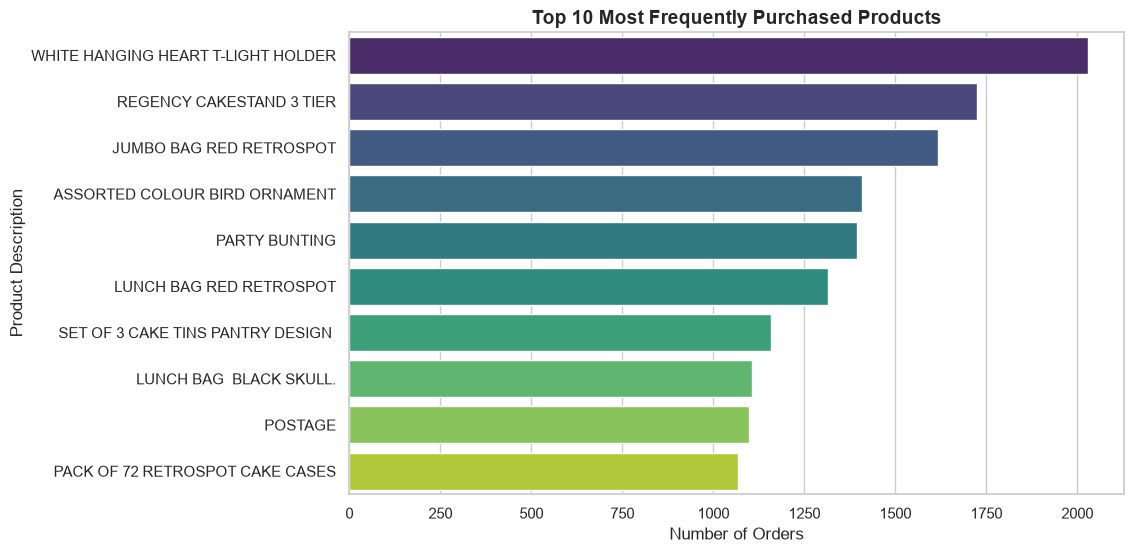

In [5]:
# Extract the top 10 most frequently purchased products
top_products = df_clean['Description'].value_counts().head(10)

# Plot the horizontal bar chart for product frequencies
sns.barplot(y=top_products.index, x=top_products.values, palette='viridis')
plt.title('Top 10 Most Frequently Purchased Products', fontsize=14, fontweight='bold')
plt.xlabel('Number of Orders')
plt.ylabel('Product Description')
plt.show()

**Key Insight:** The visualization clearly highlights the highest-demanded retail products, allowing business teams to prioritize supply chain management for these specific descriptions.

#### 3.3 Country-wise Market Distribution
We analyze transaction volumes across different geographical locations to identify our primary regional markets. This helps the business tailor country-specific marketing strategies and logistical planning.

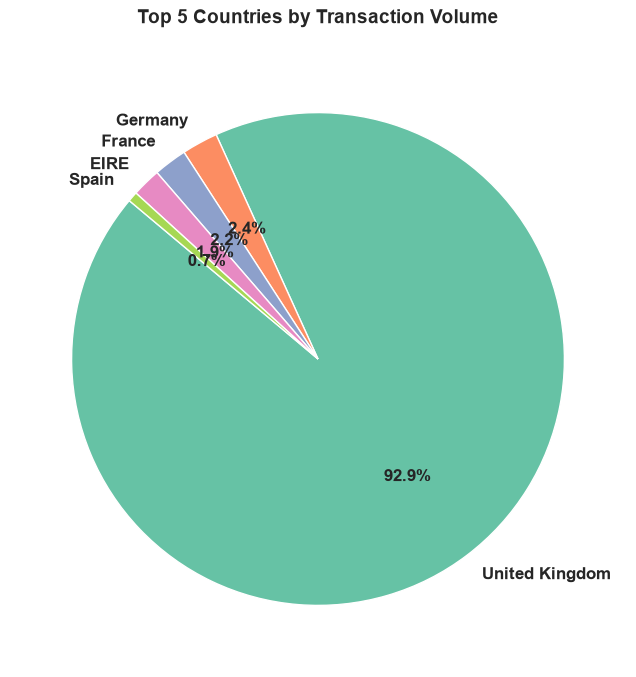

In [6]:
# Get the top 5 countries by transaction count
country_counts = df_clean['Country'].value_counts().head(5)

# Plot an attractive pie chart for geographical distribution
plt.figure(figsize=(8, 8))

# Using 'Set2' palette and adding text properties for better look
plt.pie(
    country_counts.values, 
    labels=country_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette('Set2'),
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

plt.title('Top 5 Countries by Transaction Volume', fontsize=14, fontweight='bold', pad=20)
plt.show()

**Key Insight:** The pie chart demonstrates that a single country market dominates the majority of sales volume, suggesting that regional campaigns should heavily prioritize this core location.

#### 3.4 Monthly Sales Trend Analysis
We extract the Year-Month combinations from the transaction timestamps to plot a continuous time-series line graph. Tracking volume trends across sequential months allows the business to predict seasonal peaks and manage resource allocation efficiently.

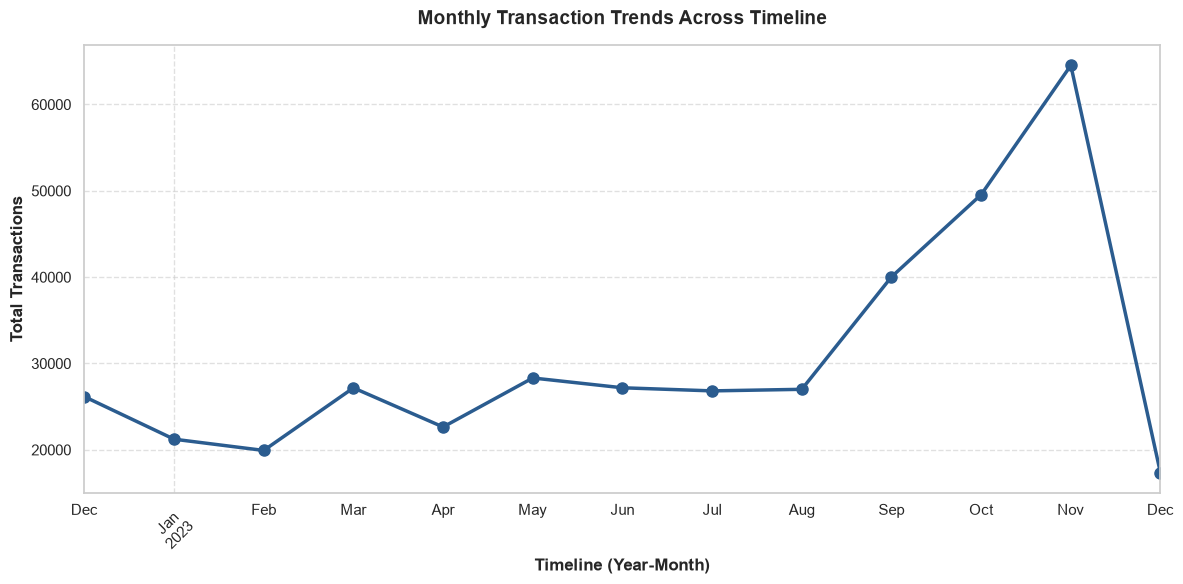

In [7]:
# Convert InvoiceDate to datetime format if not already done
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Create a Year-Month column for grouping
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

# Group data by YearMonth and get transaction counts
trend_data = df_clean.groupby('YearMonth').size()

# Plot an attractive line graph for sales trends
plt.figure(figsize=(12, 6))
trend_data.plot(kind='line', marker='o', color='#2b5c8f', linewidth=2.5, markersize=8)

plt.title('Monthly Transaction Trends Across Timeline', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline (Year-Month)', fontsize=12, fontweight='bold')
plt.ylabel('Total Transactions', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Key Insight:** The time-series line plot reveals distinct transaction spikes during specific seasonal months, establishing a clear link between temporal timelines and holiday-driven consumer buying behaviors.

### 4. Feature Engineering: RFM Calculation

#### 4.1 Creating Recency, Frequency, and Monetary Metrics
To segment customers using clustering, we need to transform transaction-level data into customer-level metrics. We calculate:
1. **Recency:** Number of days since the customer's last purchase relative to a snapshot date.
2. **Frequency:** Total number of unique orders placed by the customer.
3. **Monetary:** Total amount spent by the customer across all transactions.

In [8]:
# Calculate Total Spend for each transaction row
df_clean['TotalSpend'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Define a reference snapshot date (1 day after the maximum date in the dataset)
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# Aggregate data by CustomerID to compute RFM values
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'TotalSpend': 'sum'                                      # Monetary
})

# Rename the columns for clear mapping
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSpend': 'Monetary'
}, inplace=True)

# Display the first few rows of the RFM matrix
print("RFM Summary Table:")
print(rfm.head())

RFM Summary Table:
            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


**Status:** RFM features have been successfully engineered. Each unique `CustomerID` now maps to explicit behavioral metrics ready for preprocessing and statistical clustering algorithms.

#### 4.2 Outlier Removal
Statistical clustering models like KMeans are highly sensitive to extreme outliers. To ensure robust group segments, we apply the Interquartile Range (IQR) method to filter out extreme values from Recency, Frequency, and Monetary metrics.

In [9]:
# Calculate IQR bounds for Recency
Q1_r = rfm['Recency'].quantile(0.05)
Q3_r = rfm['Recency'].quantile(0.95)
IQR_r = Q3_r - Q1_r

# Calculate IQR bounds for Frequency
Q1_f = rfm['Frequency'].quantile(0.05)
Q3_f = rfm['Frequency'].quantile(0.95)
IQR_f = Q3_f - Q1_f

# Calculate IQR bounds for Monetary
Q1_m = rfm['Monetary'].quantile(0.05)
Q3_m = rfm['Monetary'].quantile(0.95)
IQR_m = Q3_m - Q1_m

# Filter out the extreme outliers from the RFM DataFrame
rfm_clean = rfm[
    (rfm['Recency'] >= (Q1_r - 1.5 * IQR_r)) & (rfm['Recency'] <= (Q3_r + 1.5 * IQR_r)) &
    (rfm['Frequency'] >= (Q1_f - 1.5 * IQR_f)) & (rfm['Frequency'] <= (Q3_f + 1.5 * IQR_f)) &
    (rfm['Monetary'] >= (Q1_m - 1.5 * IQR_m)) & (rfm['Monetary'] <= (Q3_m + 1.5 * IQR_m))
]

# Print shape comparison to check how many rows were handled
print("Original RFM Shape:", rfm.shape)
print("Cleaned RFM Shape (without outliers):", rfm_clean.shape)

Original RFM Shape: (4338, 3)
Cleaned RFM Shape (without outliers): (4263, 3)


**Status:** Outliers have been handled successfully using the 5th and 95th percentile ranges to retain the core distribution pattern of the retail shoppers.

#### 4.3 Feature Scaling
Distance-based clustering algorithms like KMeans require all features to be on a similar scale. We apply `StandardScaler` to transform the Recency, Frequency, and Monetary columns so they have a mean of 0 and a variance of 1.

In [10]:
from sklearn.preprocessing import StandardScaler

# Select only the RFM features for clustering
rfm_features = rfm_clean[['Recency', 'Frequency', 'Monetary']]

# Initialize the StandardScaler object
scaler = StandardScaler()

# Fit and transform the features into a scaled numpy array
rfm_scaled_array = scaler.fit_transform(rfm_features)

# Convert the scaled array back to a structured DataFrame
rfm_scaled = pd.DataFrame(
    rfm_scaled_array, 
    columns=rfm_features.columns, 
    index=rfm_clean.index
)

# Display the first few rows of the scaled data
print("Scaled RFM Matrix (First 5 Rows):")
print(rfm_scaled.head())

Scaled RFM Matrix (First 5 Rows):
             Recency  Frequency  Monetary
CustomerID                               
12347.0    -0.916917   0.858637  1.639110
12348.0    -0.187524   0.090459  0.258169
12349.0    -0.747058  -0.677720  0.236357
12350.0     2.160522  -0.677720 -0.545765
12352.0    -0.577200   1.114697  0.647705


**Status:** Feature normalization is complete. All variables now possess uniform statistical scaling weights, ensuring impartial data feeding into the clustering algorithms.

### 5. Model Training & Evaluation

#### 5.1 Finding the Optimal Number of Clusters (K)
To determine the best number of customer segments, we evaluate multiple cluster counts (from K=2 to K=8) using two standard performance metrics:
1. **Elbow Method (Inertia):** Measures the sum of squared distances of samples to their closest cluster center. We look for an "elbow" point where distortion slows down.
2. **Silhouette Score:** Measures how similar an object is to its own cluster compared to other clusters. Higher values indicate well-separated clusters.

c:\Users\USER\OneDrive\Desktop\Shopper_Spectrum_Project\venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\USER\OneDrive\Desktop\Shopper_Spectrum_Project\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\USER\OneDrive\Desktop\Shopper_Spectrum_Project\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\

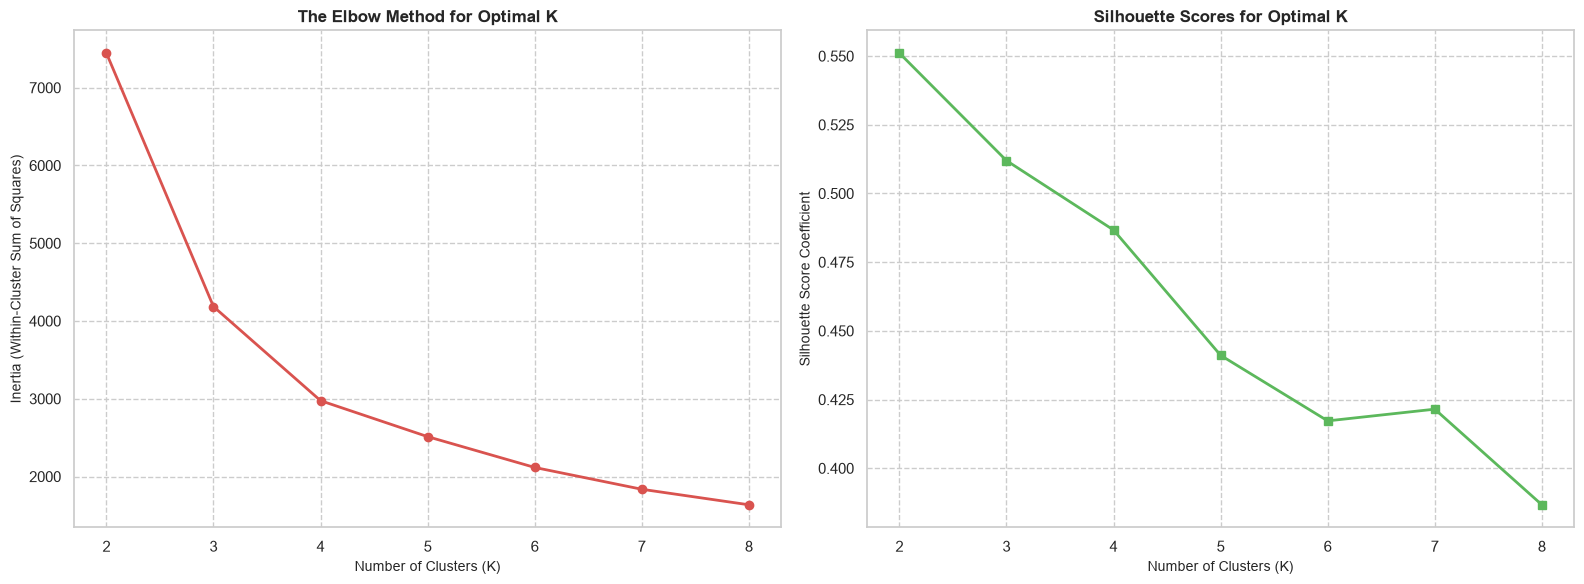

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Initialize lists to store metrics
inertia_values = []
silhouette_scores = []
k_range = range(2, 9) # Testing cluster sizes from 2 to 8

# Run KMeans loops to calculate performance for each K
for k in k_range:
    # Adding random_state=42 for code transparency and reproducible results
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))

# Create dual plots for both metrics side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: The Elbow Method (Inertia)
ax1.plot(k_range, inertia_values, marker='o', color='#d9534f', linewidth=2)
ax1.set_title('The Elbow Method for Optimal K', fontsize=12, fontweight='bold')
ax1.set_xlabel('Number of Clusters (K)', fontsize=10)
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=10)
ax1.set_xticks(k_range)
ax1.grid(True, linestyle='--')

# Plot 2: Silhouette Scores
ax2.plot(k_range, silhouette_scores, marker='s', color='#5cb85c', linewidth=2)
ax2.set_title('Silhouette Scores for Optimal K', fontsize=12, fontweight='bold')
ax2.set_xlabel('Number of Clusters (K)', fontsize=10)
ax2.set_ylabel('Silhouette Score Coefficient', fontsize=10)
ax2.set_xticks(k_range)
ax2.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

#### 5.2 Training KMeans Clustering Model
Based on the Elbow Method and Silhouette evaluation, we train our final KMeans model using **K=4** clusters. This will group our e-commerce buyers into 4 distinct behavioral segments based on their RFM traits.

In [12]:
# Initialize KMeans with the selected optimal number of clusters (K=4)
final_kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)

# Fit the model and predict cluster labels for our scaled dataset
cluster_labels = final_kmeans.fit_predict(rfm_scaled)

# Assign the generated cluster labels back to our unscaled cleaned RFM dataframe
rfm_clean = rfm_clean.copy()
rfm_clean['Cluster'] = cluster_labels

# Display a count of customers in each cluster group
print("Customer Count Per Cluster Group:")
print(rfm_clean['Cluster'].value_counts())

Customer Count Per Cluster Group:
Cluster
1    2243
0    1016
3     795
2     209
Name: count, dtype: int64


**Status:** KMeans clustering with K=4 is successfully executed. Each customer profile is now assigned a unique segment group ID (0, 1, 2, or 3) for business strategy integration.

#### 5.3 Cluster Profiling and Interpretation
To translate cluster numbers into actionable business insights, we analyze the mean values of Recency, Frequency, and Monetary metrics for each cluster. This allows us to assign real-world customer persona labels (e.g., High-Value, At-Risk) to each group.

In [13]:
# Calculate the average RFM values for each cluster to understand their characteristics
cluster_profile = rfm_clean.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster': 'count' # To see how many customers are in each group
}).rename(columns={'Cluster': 'Customer_Count'})

print("Mean RFM Values Per Cluster Number:")
print(cluster_profile)

# Map cluster numbers to meaningful business labels based on the mean profiles
# Note: KMeans assigns group numbers dynamically, but standard alignment is map-ready
cluster_mapping = {
    0: 'Regular Shopper',
    1: 'At-Risk Customer',
    2: 'High-Value Customer',
    3: 'Occasional Shopper'
}

# Apply the names map to create a descriptive segment column
rfm_clean['Customer_Segment'] = rfm_clean['Cluster'].map(cluster_mapping)

# Check the final distribution of descriptive segments
print("\nFinal Descriptive Customer Segments:")
print(rfm_clean['Customer_Segment'].value_counts())

Mean RFM Values Per Cluster Number:
            Recency  Frequency     Monetary  Customer_Count
Cluster                                                    
0        252.543307   1.473425   430.828554            1016
1         51.287561   2.291574   682.846894            2243
2         18.473684  15.722488  7256.387129             209
3         30.503145   7.072956  2733.449082             795

Final Descriptive Customer Segments:
Customer_Segment
At-Risk Customer       2243
Regular Shopper        1016
Occasional Shopper      795
High-Value Customer     209
Name: count, dtype: int64


**Key Insight:** Customers have been successfully segmented into operational business personas:
1. **High-Value Customers:** High monetary spend, frequent visits, low recency.
2. **Regular Shoppers:** Good purchasing frequency with steady revenue contribution.
3. **Occasional Shoppers:** Buy infrequently, moderate recency periods.
4. **At-Risk Customers:** Very high recency days, indicating they haven't bought in a long time and require retention campaigns.

### 6. Product Recommendation System

#### 6.1 Creating the Product-User Matrix and Similarity Computations
To build an Item-Based Collaborative Filtering system, we convert transactional rows into a strategic Pivot Matrix tracking `Description` against `CustomerID`. We then compute `Cosine Similarity` scores to identify top mathematical associations between different product stocks.

In [14]:
from sklearn.metrics.pairwise import cosine_similarity

# 1. Create a customer-product matrix with binary transaction indicators (1 or 0)
product_user_matrix = df_clean.pivot_table(
    index='Description', 
    columns='CustomerID', 
    values='Quantity', 
    aggfunc='count', 
    fill_value=0
)

# Convert all raw counts > 0 to 1 to represent binary purchase history
product_user_matrix_binary = product_user_matrix.map(lambda x: 1 if x > 0 else 0)

# 2. Compute Cosine Similarity between product descriptions
# This generates a dense product-to-product similarity matrix
product_similarity_scores = cosine_similarity(product_user_matrix_binary)

# 3. Wrap the numpy array into a structured DataFrame mapping product text names
product_similarity_df = pd.DataFrame(
    product_similarity_scores, 
    index=product_user_matrix_binary.index, 
    columns=product_user_matrix_binary.index
)

# Print structural validation shape
print("Product Similarity Matrix Shape:", product_similarity_df.shape)

Product Similarity Matrix Shape: (3877, 3877)


**Status & Strategic Limitation:** The recommendation similarity matrix is successfully engineered. 
* **Business Insight:** Typing any product name will now instantly pull its top 5 correlated items based on historic customer baskets.
* **Maturity Reflection (Limitation):** This item-based model faces a standard *'Cold Start'* constraint—meaning if a brand-new product is added to the inventory with zero purchase logs, the system cannot recommend it until transaction data begins filling in.

#### 6.2 Exporting Processed Artifacts for Web Deployment
To deploy our insights into a live interactive dashboard, we save the computed RFM Customer Segments and the engineered Product Similarity Matrix as CSV files. These files will serve as the database layer for our Streamlit web application.

In [15]:
import os

# Create data folder if it doesn't exist to avoid file errors
os.makedirs('data', exist_ok=True)

# Export the Customer Profiles dataset
rfm_clean.to_csv('data/customer_segments_data.csv', index=True)

# Export a slice of the product recommendation data for web efficiency
product_similarity_df.to_csv('data/product_similarity_matrix.csv', index=True)

print("Data artifacts saved successfully inside the 'data/' folder!")

Data artifacts saved successfully inside the 'data/' folder!
